## Code 3: Using simultaneous magnetosheath measurements to estimate magnitude uncertainty of driver

By Nithin Sivadas & Bayane Michotte de Welle

In this code, we use a database of measurements from Cluster, Double Star, THEMIS, and MMS Missions, classified into magnetosheath and solar wind (upstream of bowshock) plasma region, in order to estimate the uncertainty (or variance) in the kan-lee electric field estimated using solar wind measurements at L1 from the OMNI database relative to magnetosheath measurements made close to the subsolar point. The data we use is the output of a gradient boost classification algorithm (Nguyen et al., 2022), and distance from the magnetopause boundary is calculated using (Michotte de Welle et al., 2024). The dataset provides time stamps, satellite ID, and kan-lee electric field values of measurements made within the magnetosheath close to the subsolar point as well as solar wind measurements upstream of the bow shock. Simultaneous OMNI values are also calculated. Using this dataset we calculate the magnitude uncertainty.

In [1]:
# Initializing packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import constants as cst
from datetime import timedelta, datetime, timezone
from matplotlib.colors import LogNorm, SymLogNorm, Normalize
from scipy.ndimage import gaussian_filter as gf


from scipy import stats

from spok.models import planetary as smp
from spok import smath as sm
from spok.coordinates import coordinates as scc
from spok import utils as su

from scipy.interpolate import griddata

#from sklearn.neighbors import KNeighborsRegressor

#import speasy as spz
#from speasy.products import SpeasyVariable
from typing import List

import spacepy.omni as spo

from matplotlib.colors import LogNorm

import pickle
import gzip 

c:\Users\nithin\Documents\GitHub\polar-cap-saturation\venv\Lib\site-packages\spacepy\time.py:2448: UserWarning: Leapseconds may be out of date. Use spacepy.toolbox.update(leapsecs=True)
  _read_leaps()
C:\Users\nithin\AppData\Local\Temp\ipykernel_89068\3808846242.py:27: UserWarning: Qin-Denton/OMNI2 data not found in current format. This module has limited functionality. Run spacepy.toolbox.update(QDomni=True) to download data.
  import spacepy.omni as spo


In [3]:
# Reading Data from the reduced, compressed, and processed Pickle file
with gzip.open('/data/data_ms_cond.pkl.gz', 'rb') as f:
    data_ms = pickle.load(f)

with gzip.open('/data/data_bs_cond.pkl.gz', 'rb') as f:
    data_bs = pickle.load(f)

with gzip.open('/data/omni_ms_cond.pkl.gz', 'rb') as f:
    omni_ms = pickle.load(f)

with gzip.open('/data/omni_bs_cond.pkl.gz', 'rb') as f:
    omni_bs = pickle.load(f)


In [ ]:
data_ms_Ekl = data_ms['Ekl']   # Magnetosheath data within POS_Z<= 5RE and POS_Y<= 5 RE and R_NORM < 0.5
omni2_ms_Ekl = omni_ms['Ekl']  # Corresponding simultaneous OMNI values (L1 measurements)

data_bs_Ekl = data_bs['Ekl']   # Solar wind measurements outside the bowshock POS_Z <= 200 RE and POS_Y <= 200 RE
omni2_bs_Ekl = omni_bs['Ekl']  # Corresponding simultaneous OMNI values (L1 measurements)

In [11]:
# Calculate the variance of the data for given L1 measurement and Magnetosheath data
# -5 RE < Y < 5 RE, -5 RE < Z < 5 RE, Rnorm < 0.5
bins = np.concatenate([np.arange(0, 2, 0.1), np.arange(2, 25, 1)])
mx = []
sx = []
mx2 = []
sx2 = []


for i in range(len(bins) - 1):
    #print(i)
    cond2 =  (data_ms_Ekl>=bins[i]) & (data_ms_Ekl<bins[i+1]) 
    mx2.append(np.nanmean(omni2_ms_Ekl[cond2]))
    sx2.append(np.nanstd(omni2_ms_Ekl[cond2]))
    mx.append(np.nanmean(data_ms_Ekl[cond2]))
    sx.append(np.nanstd(data_ms_Ekl[cond2]-omni2_ms_Ekl[cond2]))

In [13]:
# Calculate the variance of the data for given L1 measurement and Solar wind data
bins = np.concatenate([np.arange(0, 2, 0.1), np.arange(2, 25, 1)])
mx_bs = []
sx_bs = []
mx2_bs = []
sx2_bs = []


for i in range(len(bins) - 1):
    #print(i)
    cond2 =  (data_bs_Ekl>=bins[i]) & (data_bs_Ekl<bins[i+1]) 
    mx2_bs.append(np.nanmean(omni2_bs_Ekl[cond2]))
    sx2_bs.append(np.nanstd(omni2_bs_Ekl[cond2]))
    mx_bs.append(np.nanmean(data_bs_Ekl[cond2]))
    sx_bs.append(np.nanstd(data_bs_Ekl[cond2]-omni2_bs_Ekl[cond2]))

### Plotting the uncertainty in solar wind kan-lee electric field for given reconnection electric field in the magnetosheath 
Kan-Lee electric field is defined as $E_{m} = V_{sw} B_{T, sw} sin^2(\theta_{cl}/2)$ (See [Kan and Lee 1979](https://doi.org/10.1029/GL006i007p00577)). But Kan and Lee derives this formula from an estimate of the projection of the reconnection electric field onto the dawn-dusk direction in the polar cap, which is equal to $E^{sh}_{m} = V_{sh} B_{sh} sin^2(\theta'/2)$ where $\theta'$ is the angle between the magnetic field in the sheath and the magnetospheric magnetic field across the magnetopause boundary. This $E_m$ is what kan and lee believes should be equal to the cross-polar cap /dawn-dusk electric field. 

By making two main assumptions:

$\theta' = \theta_{cl}$

and 

$V_{sw} B_{T,sw} = V_{sh} B_{sh}$, which is likely the case for a solar wind with $V_{sw, T} = 0$ and $B_{n,sw} = 0$. This is likely true on average for the solar wind. However, this would lead to a random difference between $E^{sh}_{m}$ and $E_{m}^{bs}$ (just upstream of the bowshock in the solar wind), though their values are same on average! In fact, though the bow shock reduces the velocity of the plasma, it increases the magnetic field such that for a solar wind with relatively low tangential velocity, the product of $V B_T$ is the same across the shock. 

Hence we plot below the variance of the L1 estimate of the kan-lee electric field for a given value of $E^{sh}_{m}$, as well as given value of $E_{kl}^{bs}$ just upstream of the shock. 

Note: Samples of data are poor for values of $E_{m}^{sh}$ > 12 mV/m, while more samples available for $E_{m}^{bs}$ > 12 mV/m". Hence the effective error that we use in our paper is the maximum value of either $E_{m}^{sh}$ or $E_{m}^{bs}$. In fact, this would be a conservative estimate. 

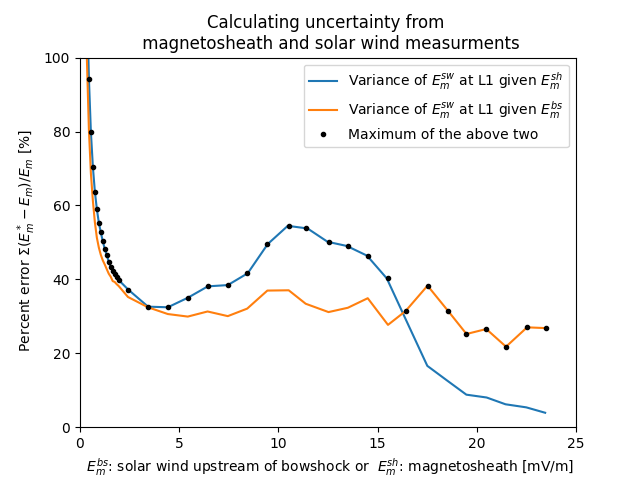

In [14]:
fig2=plt.figure()
#plt.plot(bins[0:-1],sx)
y1 = np.divide(sx_bs,mx_bs)*100
y2 = np.divide(sx,mx)*100

plt.plot(mx,np.divide(sx,mx)*100)
plt.plot(mx_bs,np.divide(sx_bs,mx_bs)*100)
plt.plot(mx_bs,np.maximum(y1, y2),'k.')
plt.ylim(0,100)
plt.xlim(0,25)
plt.ylabel(r' Percent error $\Sigma (E_{m}^* - E_{m})/E_{m}$ [%]')
plt.xlabel(r' $E_{m}^{bs}$: solar wind upstream of bowshock or  $E_{m}^{sh}$: magnetosheath [mV/m]')
plt.legend([r'Variance of $E_{m}^{sw}$ at L1 given $E_{m}^{sh}$',r'Variance of $E_{m}^{sw}$ at L1 given $E_{m}^{bs}$','Maximum of the above two'])
plt.title('Calculating uncertainty from \n magnetosheath and solar wind measurments')

#plt.plot(bins[0:-1],bins[0:-1])
fig2.savefig('/results/Figure3d_Extra1.png', dpi=300, bbox_inches='tight')
plt.show()

Uncertainty in $E^{sw-L1}_{m}$ for a given $E^{sh}_{m}$ is reliable only up to 12-15mV/m because of poor statistics beyond 12 mV/m (See the first plot in this code, Figure3d_Extra1.png), hence, its safe to assume the uncertainty for values >15 mV/m is at least as much as the variance in $E^{sw-L1}_{m}$ for a given $E^{bs-bowshock}_{m}$ value. 